# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [3]:
# import pandas
import pandas as pd
import os

In [4]:
# load the data
os.chdir('05_pandas_intro')
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [8]:
df.head()
# df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [11]:
df.count()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

How many different species are there?

In [12]:
df['species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Calculate the mean, median, mode for petal length

In [24]:
mean_val = df['petal_length'].mean()
median_val = df['petal_length'].median()
mode_val = df['petal_length'].mode()[0]

print(f"Mean: {mean_val:.2f}, Median: {median_val}, Mode: {mode_val}")

Mean: 3.76, Median: 4.35, Mode: 1.5


<Axes: xlabel='petal_length', ylabel='Count'>

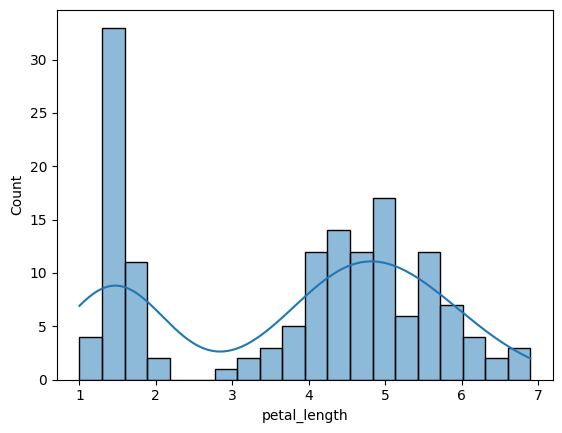

In [42]:
# df.describe()
import seaborn as sns
sns.histplot(df['petal_length'], kde=True, bins=20)


What is the smallest and largest value for petal length?

In [31]:
max_val = df.petal_length.max()
min_val = df.petal_length.min()

print(f"Min: {min_val}, Max: {max_val}")

Min: 1.0, Max: 6.9


Calculate the variance and standard deviation for petal length

In [34]:
variance = df['petal_length'].var()
std_dev = df['petal_length'].std()

print(f"Variance: {variance}, Std dev: {std_dev}")

Variance: 3.113179418344519, Std dev: 1.7644204199522626


Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [35]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [43]:
df['sepal_length'].mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [45]:
df.groupby('species').count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [49]:
df.groupby('species')[['sepal_length','sepal_width']].mean()

,sepal_length,sepal_width
species,,
Iris-setosa,5.006,3.418
Iris-versicolor,5.936,2.770
Iris-virginica,6.588,2.974


Add the sum of the sepal width and length as a new column to your DataFrame.

In [53]:
df.eval('size = sepal_width+sepal_length', inplace=True)

Visualize petal length with a histogram

array([[<Axes: title={'center': 'petal_length'}>]], dtype=object)

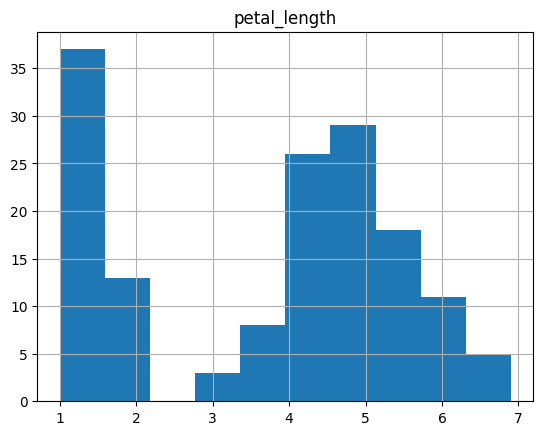

In [54]:
df.hist('petal_length')

Describe the distribution

In [ ]:
# --- Key Conclusions: Petal Length Distribution ---
#
# 1. Bimodal Shape: 
#    The distribution has two distinct peaks, meaning it's not a normal 
#    "Bell Curve". There is a clear separation between short and long petals.
#
# 2. Sub-populations: 
#    - Left peak (1.0-2.0cm): Represents 'Iris setosa'.
#    - Right cluster (3.0-7.0cm): Represents 'Iris versicolor' and 'Iris virginica'.
#
# 3. Species Separation: 
#    The "valley" at ~2.5cm shows that Petal Length is an excellent 
#    feature to classify 'setosa' from the other species.
#
# 4. Range: 
#    Values range from 1.0cm to 6.9cm, with the highest density in the 
#    very short petal category (>35 observations).

Which is more informative: the summary statistics or visualizations?

In [ ]:
# visualization

Visualize petal length and width with a "scatter_matrix"

array([[<Axes: xlabel='petal_length', ylabel='petal_length'>,
        <Axes: xlabel='petal_width', ylabel='petal_length'>],
       [<Axes: xlabel='petal_length', ylabel='petal_width'>,
        <Axes: xlabel='petal_width', ylabel='petal_width'>]], dtype=object)

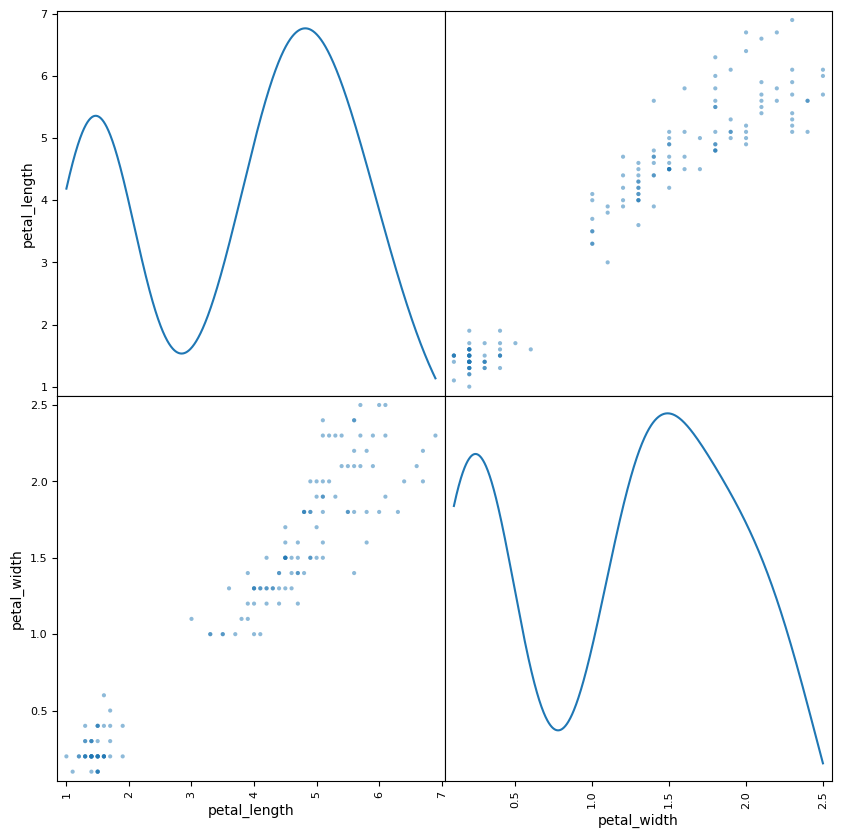

In [58]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[['petal_length', 'petal_width']], figsize=(10, 10), diagonal='kde')

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [59]:
df.eval('petal_area_est = petal_length*petal_width', inplace = True)
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'size', 'petal_area_est'],
      dtype='str')

Create a new DataFrame with petal areas greater than $1cm^2$.

In [62]:
sample_df = df[df['petal_area_est'] > 1]
sample_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,size,petal_area_est
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [65]:
Iris_setosa_df = df[df['species'] == 'Iris-setosa']
Iris_versicolor_df = df[df['species'] == 'Iris-versicolor']
Iris_virginica_df = df[df['species'] == 'Iris-virginica']
